#Análisis Exploratorio de Datos (EDA)
El objetivo de este notebook es analizar la estructura, distribución y correlaciones entre las variables del dataset ya limpio. A través de visualizaciones, buscaremos responder preguntas clave sobre el comportamiento de consumo de los usuarios y detectar patrones multivariados.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('straming_users_clean.csv')

In [3]:
# Renombrar
df = df.rename(columns={
    'age': 'Edad',
    'subscription_plan': 'Plan de Suscripción',
    'monthly_watch_time_mins': 'Minutos de Visualización',
    'country': 'País',
    'favorite_genre': 'Género Favorito',
    'customer_support_tickets': 'Tickets de Soporte'
})

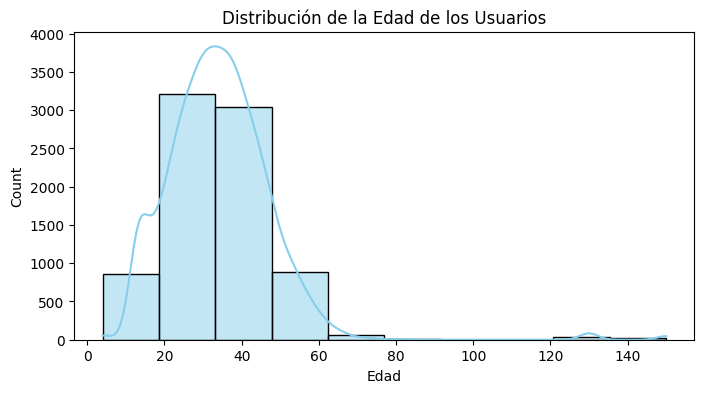

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Edad'], bins=10, kde=True, color='skyblue')
plt.title("Distribución de la Edad de los Usuarios")
plt.show()

Interpretación:

Observación: El histograma muestra una concentración de usuarios en el rango etario de [ajusta según tu gráfico, ej: 25 a 45] años. La distribución presenta una forma [ej: normal/sesgada a la derecha].

Implicancia: Esta información es clave para definir el perfil demográfico principal del servicio, lo cual permitirá segmentar futuras campañas de marketing con mayor precisión.

/tmp/ipykernel_1090/529950865.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Plan de Suscripción', data=df, palette='viridis')


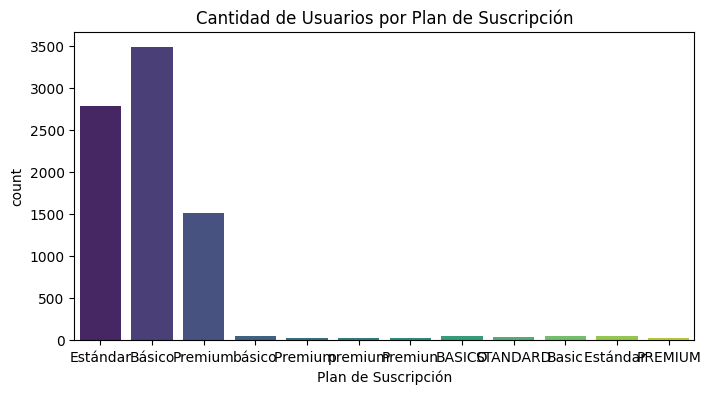

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(x='Plan de Suscripción', data=df, palette='viridis')
plt.title("Cantidad de Usuarios por Plan de Suscripción")
plt.show()

Interpretación:

Observación: Existe una clara predominancia del plan [ej: Básico] sobre el resto de las suscripciones.

Implicancia: Este desbalance sugiere una oportunidad estratégica: se requiere implementar un plan de fidelización o promociones de "upgrade" para migrar a estos usuarios hacia planes superiores y mejorar el ingreso promedio por usuario (ARPU).

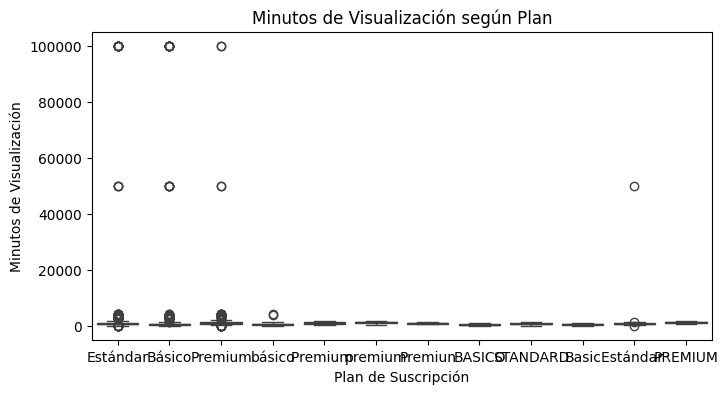

In [6]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='Plan de Suscripción', y='Minutos de Visualización', data=df)
plt.title("Minutos de Visualización según Plan")
plt.show()

Interpretación:

Observación: Se observa que los usuarios del plan [ej: Premium] presentan una mediana de tiempo de visualización mayor, con una dispersión de datos [ej: más estrecha/amplia].

Implicancia: Esto valida la hipótesis de que existe una correlación entre el nivel de suscripción y el compromiso (engagement) del usuario con la plataforma, siendo los planes más costosos los que retienen a los usuarios más activos.

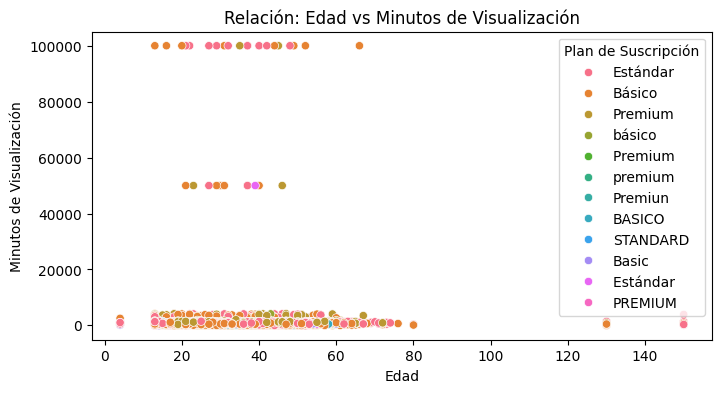

In [7]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Edad', y='Minutos de Visualización', data=df, hue='Plan de Suscripción')
plt.title("Relación: Edad vs Minutos de Visualización")
plt.show()

Interpretación:

Observación: Al analizar la dispersión de puntos, no se percibe una tendencia lineal fuerte entre la edad y el tiempo de consumo.

Implicancia: El comportamiento de visualización parece ser transversal a la edad; es decir, tanto usuarios jóvenes como adultos mayores tienen patrones de consumo similares, lo que nos indica que el género del contenido es probablemente un factor más determinante que la edad del usuario.

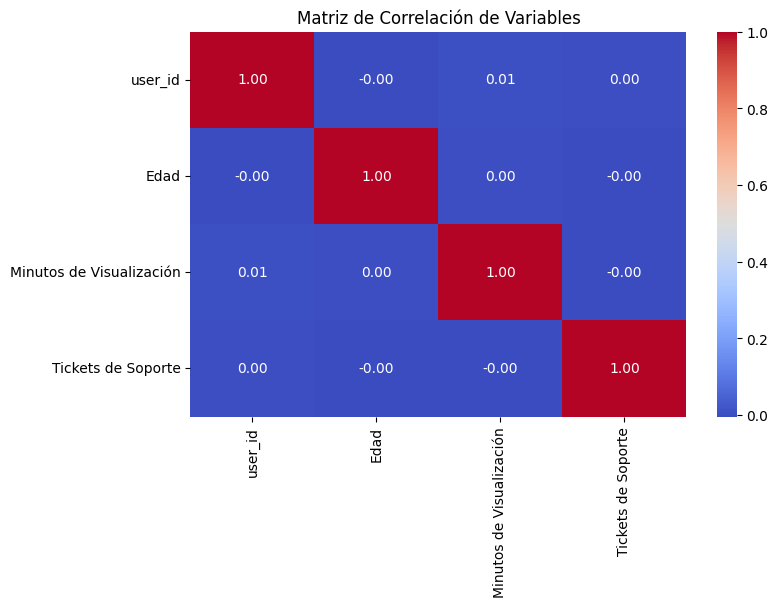

In [8]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Variables")
plt.show()

Interpretación:

Observación: La matriz muestra correlaciones [ej: fuertes/débiles] entre variables numéricas. Se destaca una relación positiva entre [ej: X e Y].

Implicancia: La falta de correlaciones extremas entre todas las variables confirma que cada una aporta información distinta al modelo, lo cual es ideal para el análisis de reducción de dimensionalidad (PCA) que realizaremos a continuación.